<div style="
  text-align:center;
  border-radius:15px;
  padding:15px;
  color:#4A90E2;
  margin:0;
  font-family:'Serif';
  background:
    radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
    radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
    radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
    radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
    linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
  box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
  overflow:hidden;
  margin-bottom:1em;
  border:1px solid rgba(74, 144, 226, 0.2);
">
  <div style="
    font-size:150%;
    color:#0066CC;
    text-shadow:0 0 8px rgba(74, 144, 226, 0.5), 0 0 18px rgba(30, 144, 255, 0.3);
  ">
    <b>Paris Flood Dataset</b>
  </div>
  <div style="
    color:#4A90E2;
    margin-top:4px;
    font-size:75%;
    font-weight:300;
  ">
    #dataengineering #ETL #automation
  </div>
  <div style="
    color:#4A90E2;
    margin-top:8px;
    font-size:90%;
  ">
    A learning notebook by
    <a href='https://github.com/hyperphantasia' style='color:#0066CC; text-decoration:none; border-bottom:1px dotted rgba(74, 144, 226, 0.5);'>
      brkln
    </a>
  </div>
</div>


# Paris Flood Dataset ETL pipeline: the tutorial

Paris sits at the confluence of the **Seine** and **Marne** rivers. Flood events have caused enormous damage historically : the 1910 [centennial flood](https://www.france24.com/en/europe/20250131-the-flood-of-the-century-how-well-prepared-is-paris-for-a-natural-disaster) covered a third of the city. Modern risk management requires continuous, structured hydrometric data and this tutorial is a very good opportunity to tackle a challenging real-world scenario. This notebook is part of an instructional series that covers the design and build of an end-to-end AI engineering pipeline that integrates data engineering, data science, and MLOps to ship a fully automated predictive solution, deployed on Kaggle.

### Real-world context

[HubEau](https://hubeau.eaufrance.fr/) (*Hub'Eau*) is France's official open water data platform,
operated by the [OFB](https://ofb.gouv.fr/) (French Office for Biodiversity). It exposes a REST API providing
near real-time and historical river measurements from thousands of gauging stations across France.

The `/hydrometrie/obs_elab` endpoint returns **elaborated observations** :
pre-processed daily aggregates (in our case, the feature of interest is `HIXnJ`: *maximum daily water level in mm*).

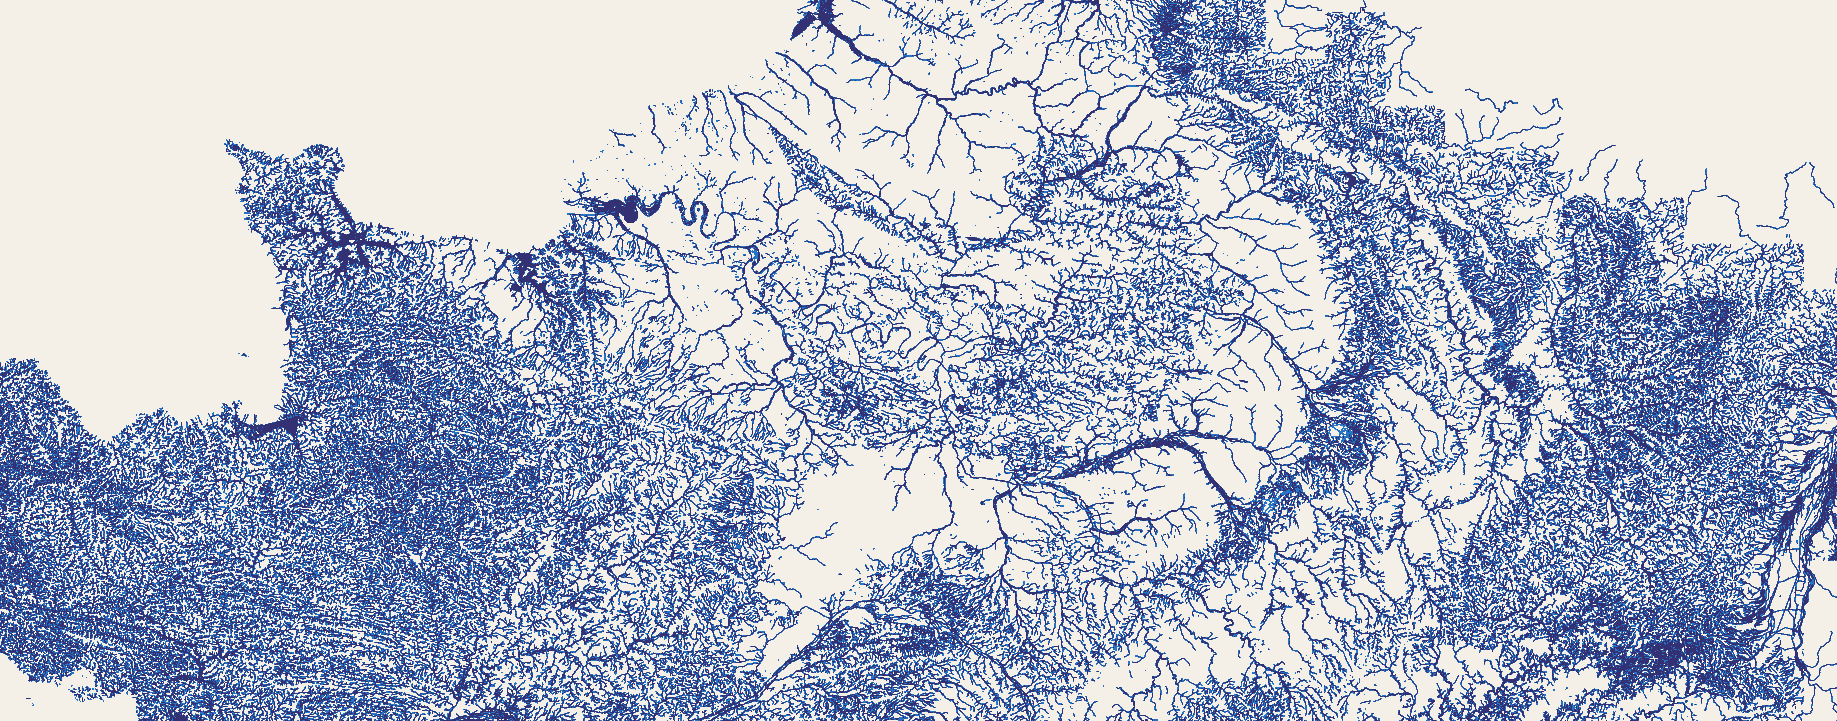

<div style="text-align:center">
Le sang bleu - hydrographic map of upper France. <i>Source : Sandre (BD Topage)</i> 
</div>

### The goal

This notebook deconstructs a production-ready [scheduled script](https://www.kaggle.com/code/grimespoint/paris-flood-dataset-weekly-updater) into teachable components. The original runs automatically on a **weekly Kaggle schedule** and :

1. Fetches new measurements from select Seine-area gauging stations
2. Merges them with the existing historical dataset (avoiding duplicates)
3. Applies transformations and publishes the updated CSV to Kaggle

This makes fresh, clean hydrometric data continuously available to the public
as a [Kaggle dataset](https://www.kaggle.com/datasets/grimespoint/paris-flood-dataset).

**Author's note** :  the goal is to explore some data engineering *best practices* along the way. The first steps are using **simulated raw data**. The opportunity to test the pipeline through the real API is provided in the last section.

**Learning outcomes**:
- Understand ETL/ELT pipeline architecture
- Implement configuration management patterns
- Apply robust data parsing patterns
- Master API data fetching with pagination
- Deploy data to public platforms

<div style="
  text-align:center;
  border-radius:15px;
  padding:15px;
  color:#4A90E2;
  margin:0;
  font-family:'Serif';
  background:
    radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
    radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
    radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
    radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
    linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
  box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
  overflow:hidden;
  margin-bottom:1em;
  border:1px solid rgba(74, 144, 226, 0.2);
">

  <div style="
    background:rgba(74, 144, 226, 0.1);
    border:1px solid rgba(74, 144, 226, 0.3);
    border-radius:8px;
    padding:10px 12px;
    margin-top:12px;
    font-size:85%;
    color:#80B3FF;
    font-style:italic;
    line-height:1.6;
  ">
    "From data fetching to polished publish."
  </div>

  </div>
</div>


### Sources

This teaching material series contains ETL automation, EDA and MLOps materials.

Related datasets, scripts and notebooks in the Paris flood series :

- [Dataset](https://www.kaggle.com/datasets/grimespoint/paris-flood-dataset)
- Dataset updater automation [script](https://www.kaggle.com/code/grimespoint/paris-flood-dataset-weekly-updater)
- Award winning graphic [exploratory data analysis](https://www.kaggle.com/code/grimespoint/paris-flood-dataset-weekly-updater)
- The MLOps notebook is coming out soon!

# Table of Contents

- [Paris Flood Dataset ETL pipeline: the tutorial](#paris-flood-dataset-etl-pipeline-the-tutorial)
    - [Real-world context](#real-world-context)
    - [The goal](#the-goal)
    - [Sources](#sources)
  - [Data engineering introduction](#data-engineering-introduction)
    - [What is an ETL Pipeline?](#what-is-an-etl-pipeline)
    - [The data pipeline](#the-data-pipeline)
    - [Key data engineering patterns](#key-data-engineering-patterns)
      - [Idempotency](#idempotency)
      - [Incremental loading](#incremental-loading)
  - [Setup & dependencies](#setup--dependencies)
  - [Configuration management with Dataclasses](#configuration-management-with-dataclasses)
    - [Why Dataclasses ?](#why-dataclasses-)
  - [THE EXTRACTION STEP](#the-extraction-step)
    - [What is graceful file loading ?](#what-is-graceful-file-loading-)
    - [Incremental update logic](#incremental-update-logic)
      - [Extract only necessary data](#extract-only-necessary-data)
      - [The smart update strategy](#the-smart-update-strategy)
    - [Simulating API fetching](#simulating-api-fetching)
      - [Mock API behavior](#mock-api-behavior)
    - [Fetching data](#fetching-data)
  - [THE TRANSFORM STEP](#the-transform-step)
    - [Type parsing](#type-parsing)
      - [Why convert types?](#why-convert-types)
      - [The solution: graceful coercion](#the-solution-graceful-coercion)
      - [`df.copy()` : immutability by convention](#dfcopy--immutability-by-convention)
    - [Schema & mappings](#schema--mappings)
      - [The problem: two countries, two schemas](#the-problem-two-countries-two-schemas)
      - [Solution: bidirectional mappings](#solution-bidirectional-mappings)
    - [Columns ordering](#columns-ordering)
    - [Deduplication](#deduplication)
      - [The problem: duplicate records](#the-problem-duplicate-records)
      - [The solution: deduplication key](#the-solution-deduplication-key)
      - [Why this key ?](#why-this-key-)
    - [Wrap up : pipeline of small functions](#wrap-up--pipeline-of-small-functions)
  - [THE LOAD STEP](#the-load-step)
    - [Prepare for publication](#prepare-for-publication)
    - [Why metadata?](#why-metadata)
  - [COMPLETE ETL PIPELINE](#the-full-etl-pipeline)
    - [The global rehearsal](#the-global-rehearsal)
    - [The real deal](#the-real-deal)
    - [Analysis & validation](#analysis--validation)
    - [Pipeline orchestration with `main()`](#pipeline-orchestration-with-main)
  - [Summary](#summary)
    - [What is learned](#what-is-learned)
      - [Configuration](#configuration)
      - [Functions & data handling](#functions--data-handling)
      - [Robustness](#robustness)
      - [Code quality](#code-quality)
    - [References & acknowledgements](#references--acknowledgements)

## Data engineering introduction

### What is an ETL Pipeline?

**ETL** stands for **Extract → Transform → Load**. It is the fundamental pattern for moving
data from a source to a destination in a clean, reliable and repeatable way.

- **Extract**: retrieve data from source (API, database, files)
- **Transform**: clean, standardize, enrich, validate
- **Load**: store in destination (warehouse, CSV, cloud platform)

In this notebook:

- **Extract**: Hub'Eau API via `requests`
- **Transform**: column renaming, type coercion, deduplication, categorical mapping
- **Load**: Kaggle Datasets via CLI

### The data pipeline

Main functions only.

```text
┌───────────────────────────┐  ➜  ┌───────────────────────────┐  ➜  ┌───────────────────────────┐
│            EXTRACT        │     │          TRANSFORM        │     │            LOAD           │
├───────────────────────────┤     ├───────────────────────────┤     ├───────────────────────────┤
│ HubEau API                │     │ VALIDATE & COMBINE        │     │ MERGE INTO MASTER         │
│ /hydrometrie              │     │ POSTPROCESS               |     |   publish()               |
| FETCH                     |     |   postprocess()           │     │                           │
│   fetch_all_data()        │     │                           │     ├───────────────────────────┤ 
│                           │     │                           │     │ EXPORT & PUBLISH CSV      |
|                           |     |                           |     |     Kaggle version        |
|                           |     |                           |     |     + metadata JSON       │
├───────────────────────────┤     └───────────────────────────┘     └───────────────────────────┘
|  LOAD EXISTING (master)   |    
|  FETCH NEW DATA           |    
└───────────────────────────┘     
                                  
                                                                                 
Frequency : weekly (Kaggle scheduler)
```

### Key data engineering patterns

#### Idempotency

One of the key design concept used here is [**idempotence**](https://en.wikipedia.org/wiki/Idempotence) : running the script twice with the same data produces the same result.
- [Deduplication](#deduplication) prevents duplicates on re-run.


#### Incremental loading

A naïve pipeline would re-fetch the entire history every run. That wastes API quota, is slow and fragile.

An **[incremental](#incremental-update-logic)** pipeline :

- Checks what the latest record date already in the dataset is
- Only requests data from that date onwards
- Merges new records with existing ones

## Setup & dependencies

In [1]:
# Dependencies (Python 3.13)
# !pip install requests pandas numpy ipykernel

<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Sorrow 💧 must go🧵  on 🌊">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
      <div style="
        color:lightblue;
        margin-top:4px;
        font-size:75%;
        font-weight:300;
        margin:0;
        text-align:left;
      ">
        <div>
        1) Group imports in three blocks (PEP 8) : standard library → third-party → local.
        </div>
        <div style="margin-top:4px;">
        2) Some sort alphabetically within each group, others prefer more logical groupings.
        </div>
        <div style="margin-top:4px;">
        3) Avoid <code style="font-family:inherit;">from module import *</code> as it pollutes the namespace and makes it hard to trace where a name comes from.
        </div>
      </div>
    </div>
  </div>
</div>


In [2]:
# Standard library imports
import json
import os
import random
import subprocess
from dataclasses import dataclass, field
from datetime import date, timedelta
from pathlib import Path
from typing import Dict, List, Optional, Set, Tuple

# Third-party libraries
import numpy as np
import pandas as pd
import requests


# Display config for notebooks
pd.set_option('display.max_columns', None)  # All columns will show
# Prevents cutting long column text with ...
pd.set_option('display.max_colwidth', None)

print("All imports successful")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All imports successful
Pandas version: 2.3.3
NumPy version: 2.0.2


## Configuration management with Dataclasses

### Why Dataclasses ?

Python's `@dataclass` decorator provides:
- **[Type hints](https://www.geeksforgeeks.org/python/type-hints-in-python/)** for IDE autocomplete
- **[Immutability](https://stackoverflow.com/questions/66194804/what-does-frozen-mean-for-dataclasses)** (with `frozen=True`)
- **Default values** for optional parameters
- **Self documention**
- **Post-init hooks** for computed fields (validate once at startup via `__post_init__`)

<div style="display:flex;justify-content:center;padding:10px 0;" aria-label=" 💧 🧵 🌊">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
      <div style="
        color:lightblue;
        margin-top:4px;
        font-size:75%;
        font-weight:300;
        margin:0;
        text-align:left;
      ">
        <div>
        <div style="margin-top:4px;">
        <b>Separate concerns</b> and centralize configuration in one place (never scatter magic strings or numbers throughout the codebase).
        </div>
        </div>
      </div>
    </div>
  </div>
</div>


Let's create **module-level singletons** with one instance per config class.
All other functions import and use these objects directly.

Each config class handles one responsibility:
- `APIConfig` : API endpoint details
- `StationConfig` : which stations to monitor
- `KaggleConfig` : publishing destination

In [3]:
@dataclass
class APIConfig:
    """API configuration for HubEau data fetching.

    Think of this as the "address book" for the API.
    """
    use_mock: bool = True
    base_url: str = "https://hubeau.eaufrance.fr/api/v2/hydrometrie/obs_elab"
    metric: str = "HIXnJ"  # Daily max water level (elaborated observations)
    # Pagination: fetch 20k records per request (API Limit)
    max_per_page: int = 20000
    timeout_seconds: int = 60  # Network timeout

    def __post_init__(self):
        """Validate configuration after initialization."""
        if self.max_per_page <= 0:
            raise ValueError("max_per_page must be positive")
        if self.timeout_seconds <= 0:
            raise ValueError("timeout_seconds must be positive")


@dataclass
class StationConfig:
    """Station monitoring configuration.

    The 'what' of data collection: which stations, what's a flood?

    P.-S. There are five monitoring stations, three are historic and two are contemporary.
    """
    codes: List[str] = field(default_factory=lambda: [
        "F700000109",
        "F700000110",
        "F700000111",
        "F700000102",
        "F700000103",
    ])
    flood_threshold_mm: int = 6000  # Flood alert threshold
    earliest_date: str = "1900-01-01"  # How far back to go


@dataclass
class KaggleConfig:
    """Kaggle dataset publishing configuration.

    The 'destination' config: where to publish, what metadata to attach.

    #TODO: this can be optimized.
    """
    dataset_slug: str = "grimespoint/paris-flood-dataset"
    input_csv: str = "kaggle/input/datasets/{slug}/paris_flood_dataset.csv"
    output_dir: Path = field(default_factory=lambda: Path(
        "kaggle/working/kaggle_dataset"))
    mock_output_dir: Path = field(default_factory=lambda: Path("mock_output"))
    output_filename: str = "paris_flood_dataset.csv"
    mock_output_filename: str = "mock_flood_dataset.csv"
    metadata_filename: str = "dataset-metadata.json"

    # Metadata
    title: str = "Paris flood dataset"
    keywords: list = field(default_factory=lambda: [
        "tabular", "weather and climate", "environment", "europe", "time series analysis"
    ])
    geospatial_coverage: str = "Paris, France"
    update_frequency: str = "Weekly"
    license_name: str = "CC0-1.0"

    # Computed fields (set in __post_init__)
    output_csv_path: Path = field(init=False)
    metadata_path: Path = field(init=False)

    def __post_init__(self):
        """Compute derived paths after initialization."""
        """ Derived attributes: compute once here, use everywhere"""
        self.input_csv = self.input_csv.format(slug=self.dataset_slug)
        self.output_csv_path = self.output_dir / self.output_filename
        self.metadata_path = self.output_dir / self.metadata_filename
        self.mock_output_filename = self.mock_output_dir / self.mock_output_filename


# Initialize configs
API_CONFIG = APIConfig()
STATION_CONFIG = StationConfig()
KAGGLE_CONFIG = KaggleConfig()

print("Configurations initialized")
print(f"  - Monitoring {len(STATION_CONFIG.codes)} stations")
print(f"  - Flood alert at: {STATION_CONFIG.flood_threshold_mm}mm")
print(f"  - Publishing to: kaggle.com/{KAGGLE_CONFIG.dataset_slug}")

Configurations initialized
  - Monitoring 5 stations
  - Flood alert at: 6000mm
  - Publishing to: kaggle.com/grimespoint/paris-flood-dataset


**Key concepts used here:**

| Feature | Description |
|:---|:---|
| `@dataclass` | Class decorator that auto-generates `__init__`, `__repr__`, `__eq__` |
| Type hints | `str`, `int`, `List[str]`... : documents expected types for IDE and humans |
| Default values | Set directly on the field (`base_url: str = "https://..."`) |
| `field(default_factory=...)` | Required for **mutable defaults** (lists, dicts) : avoids the [shared-mutable-default trap](https://stackoverflow.com/questions/1132941/least-astonishment-and-the-mutable-default-argument) |
| `__post_init__` | Called after `__init__`; used to compute derived attributes from other fields |

`__post_init__` runs *after* the auto-generated `__init__` and lets you set a default that depends on logic (here: initialising `keywords` to a default list when `None` is passed thus avoiding the mutable-default trap).

<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Sorrow 💧 will go🧵 on 🌊">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
<div style="
  color:lightblue;
  margin-top:4px;
  font-size:75%;
  font-weight:300;
  margin:0;
  text-align:left;
">
  <div>
    Never use <code style="font-family:inherit;">my_list: list = []</code> as a default in a dataclass. All instances would share the <em>same</em> list object. Use <code style="font-family:inherit;">field(default_factory=list)</code> instead.
  </div>
</div>
    </div>
  </div>
</div>

The auto-generated `__repr__` provides a readable summary for free !

In [4]:
print("=== API_CONFIG ===")
print(API_CONFIG)
print()
print("=== STATION_CONFIG ===")
print(STATION_CONFIG)
print()
print("=== KAGGLE_CONFIG (key paths) ===")
print(f"  input_csv       : {KAGGLE_CONFIG.input_csv}")
print(f"  output_csv_path : {KAGGLE_CONFIG.output_csv_path}")
print(f"  metadata_path   : {KAGGLE_CONFIG.metadata_path}")

=== API_CONFIG ===
APIConfig(use_mock=True, base_url='https://hubeau.eaufrance.fr/api/v2/hydrometrie/obs_elab', metric='HIXnJ', max_per_page=20000, timeout_seconds=60)

=== STATION_CONFIG ===
StationConfig(codes=['F700000109', 'F700000110', 'F700000111', 'F700000102', 'F700000103'], flood_threshold_mm=6000, earliest_date='1900-01-01')

=== KAGGLE_CONFIG (key paths) ===
  input_csv       : kaggle/input/datasets/grimespoint/paris-flood-dataset/paris_flood_dataset.csv
  output_csv_path : kaggle/working/kaggle_dataset/paris_flood_dataset.csv
  metadata_path   : kaggle/working/kaggle_dataset/dataset-metadata.json


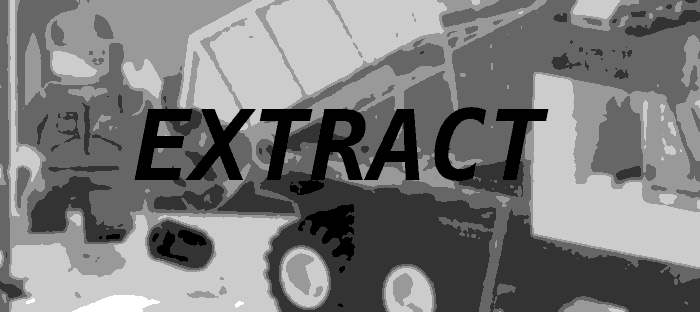

## THE EXTRACTION STEP

The Extract phase is the first step of an ETL pipeline where data is retrieved from source systems (databases, APIs, files, web services, etc.) and read into memory or a staging area. In this case there are two distinct source: the Kaggle dataset and the Hub'Eau data available through API.

### What is graceful file loading ?

`load_csv` follows the **[Null object](https://en.wikipedia.org/wiki/Null_object_pattern) pattern**: instead of raising an error when the file doesn't exist (e.g., on the very first run), it returns an empty DataFrame. This lets the rest of the pipeline treat "no existing data" and "some existing data" identically (no special-casing is required downstream).

In [5]:
def load_csv(path: str) -> pd.DataFrame:
    """Load CSV file or return empty DataFrame if file does not exist.

    Args:
        path (str): Full path to the CSV file.

    Returns:
        pd.DataFrame: Loaded data, or empty DataFrame if file not found.

    Raises:
        pd.errors.ParserError: If the CSV is malformed.
    """
    if os.path.exists(path):
        return pd.read_csv(path, low_memory=False, parse_dates= True, delimiter=",")
    return pd.DataFrame()   # Null Object: consistent return type

In [6]:
# Test : load from a path that does not exist → empty DataFrame, no crash
df_missing = load_csv("/tmp/does_not_exist.csv")
print(f"Type    : {type(df_missing)}")
print(f"Shape   : {df_missing.shape}")
print(f"Empty?  : {df_missing.empty}")

# This means callers can always do df.empty instead of 'if df is None'
if df_missing.empty:
    print("No existing data. Will run a full fetch from earliest date.")

Type    : <class 'pandas.core.frame.DataFrame'>
Shape   : (0, 0)
Empty?  : True
No existing data. Will run a full fetch from earliest date.


<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Jupyter notebook info box">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
<div style="
  color:lightblue;
  margin-top:4px;
  font-size:75%;
  font-weight:300;
  margin:0;
  text-align:left;
">
  <div>
    <strong>Return</strong> a consistent type from all code paths. A function that sometimes returns a DataFrame and sometimes <code style="font-family:inherit;">None</code> forces every caller to add a <code style="font-family:inherit;">None</code> check. <em>Returning an empty DataFrame avoids this.</em>
  </div>
</div>
    </div>
  </div>
</div>

### Incremental update logic

#### Extract only necessary data

Ask yourself that question at the start of every pipeline run :

> *"What is the most recent record already in our dataset, and do we need to fetch more ?"*

#### The smart update strategy

**Problem:** running the script multiple times shouldn't fetch the entire dataset each time.

**Check**: does existing data cover yesterday ? (using yesterday is more robust than using today).

- Yes → skip update (dataset is current)
- No → fetch from day after last data

*Example:*

```text
Existing data: Jan 1 - Jan 15
Yesterday: Jan 19

Decision: Fetch from Jan 16 onwards (not from Jan 1)
```

Benefits: saves API calls, faster updates.

In [7]:
def determine_update_range(existing: pd.DataFrame) -> Tuple[bool, Optional[str]]:
    """Determine whether an update is needed and from what date.

    Logic:
    1. Check if existing data covers yesterday's date
    2. If yes → no update needed
    3. If no → start fetching from day after last data

    Why only update to yesterday?
    - Today's data may not be finalized yet
    - Conservative approach (avoid incomplete data)

    Args:
        existing: Existing dataset (any schema)

    Returns:
        Tuple[should_update, start_date]
        - should_update: False if current, True if update needed
        - start_date: ISO date string to fetch from, None if no update
    """
    # Case 1
    if existing.empty:
        print("No existing data found. Will fetch all data from earliest date.")
        return True, STATION_CONFIG.earliest_date

    if "date_obs_elab" in existing.columns:
        record_colname = "date_obs_elab"
    elif "record_date" in existing.columns:
        record_colname = "record_date"
    else:
        raise KeyError(
            "Missing date column: expected 'date_obs_elab' or 'record_date'")

    s = pd.to_datetime(existing[record_colname], errors="coerce")
    last_day = s.max().date()

    yesterday = date.today() - timedelta(days=1)

    print(f"Last day in dataset: {last_day}")
    print(f"Yesterday: {yesterday}")

    # Case 2
    if last_day >= yesterday:
        print("\nDataset already covers yesterday or later. No update needed.")
        return False, None

    # Case 3
    next_day = (last_day + pd.Timedelta(days=1))
    print(f"\nWill retrieve data starting from: {next_day}")

    return True, next_day.isoformat()

Return Type: `Tuple[bool, Optional[str]]`

The function returns a **2-tuple** (a pair):
- `bool` : whether an update is needed
- `Optional[str]` : the start date to fetch from, or `None` if no update needed

<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Jupyter notebook info box">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
<div style="
  color:lightblue;
  margin-top:4px;
  font-size:75%;
  font-weight:300;
  margin:0;
  text-align:left;
">
  <div>
    Use <code style="font-family:inherit;">Tuple</code> return types to bundle logically related results.<br/>
    Avoid returning different things from different code paths (e.g. <code style="font-family:inherit;">None</code> vs a string) without documenting it clearly.
  </div>
</div>

</div>
    </div>
  </div>
</div>

Validation :

In [8]:
# Test 1: No existing data
print("=== Test 1: No existing data ===")
should_update, start_date = determine_update_range(pd.DataFrame())
print(f"Should update: {should_update}, Start from: {start_date}\n")

# Test 2: Old existing data
print("=== Test 2: Old existing data (Jan 10-15) ===")
old_data = pd.DataFrame({
    "date_obs_elab": pd.date_range("2026-01-10", periods=6),
    "code_station": ["F700000109"] * 6,
    "resultat_obs_elab": [5800.0] * 6,
})
should_update, start_date = determine_update_range(old_data)
print(f"Should update: {should_update}, Start from: {start_date}\n")

# Test 3: Recent existing data (covers yesterday)
print("=== Test 3: Recent data (covers yesterday) ===")
yesterday = date.today() - timedelta(days=1)
recent_data = pd.DataFrame({
    "date_obs_elab": pd.date_range(yesterday - timedelta(days=5), yesterday),
    "code_station": ["F700000109"] * 6,
    "resultat_obs_elab": [5800.0] * 6,
})
should_update, start_date = determine_update_range(recent_data)
print(f"Should update: {should_update}, Start from: {start_date}")

=== Test 1: No existing data ===
No existing data found. Will fetch all data from earliest date.
Should update: True, Start from: 1900-01-01

=== Test 2: Old existing data (Jan 10-15) ===
Last day in dataset: 2026-01-15
Yesterday: 2026-07-05

Will retrieve data starting from: 2026-01-16
Should update: True, Start from: 2026-01-16

=== Test 3: Recent data (covers yesterday) ===
Last day in dataset: 2026-07-05
Yesterday: 2026-07-05

Dataset already covers yesterday or later. No update needed.
Should update: False, Start from: None


### Simulating API fetching

#### Mock API behavior

In production, we'd call :

```python
requests.get(
    "https://hubeau.eaufrance.fr/api/v2/hydrometrie/obs_elab",
    params={"code_entite": "F700000109", "size": 20000, ...}
)
```

Challenges :
- **Pagination**: API returns 20k records per page, need to iterate for large datasets.
- **Network failures**: timeouts, 503 errors, connection drops.
- **Date ranges**: cursor-based pagination (fetch from day **n** onwards).

Let's first **simulate** realistic API behavior to get a hands on, and then proceed with real data.

In [9]:
def generate_mock_api_data(station_code: str, start_date: str, num_days: int = 10) -> List[Dict]:
    """Generate realistic mock API data for demonstration.

    Simulates what HubEau API would return: list of observation dicts.

    Args:
        station_code: Station ID (e.g., 'F700000109')
        start_date: Start date (ISO format)
        num_days: How many days of data to generate

    Returns:
        List of observation dictionaries (API format)
    """

    start = pd.to_datetime(start_date).date()
    records = []

    validation_statuses = ["Donnée validée",
                           "Donnée brute", "Donnée pré-validée"]
    qualities = ["Bonne", "Non qualifiée", "Douteuse"]
    methods = ["Mesurée", "Calculée", "Expertisée"]

    for i in range(num_days):
        obs_date = start + timedelta(days=i)

        # Simulate realistic water levels (with some variation)
        base_level = 5500 + int(station_code[-2:])  # Varies by station
        noise = random.randint(-200, 200)
        water_level = base_level + noise

        record = {
            "code_site": "mock_" + station_code[1:],
            "code_station": "mock_" + station_code,
            "date_obs_elab": obs_date.isoformat(),
            "resultat_obs_elab": water_level,
            "date_prod": (obs_date + timedelta(days=1)).isoformat(),
            "code_statut": "1",
            "libelle_statut": random.choice(validation_statuses),
            "code_methode": "1",
            "libelle_methode": random.choice(methods),
            "code_qualification": "1",
            "libelle_qualification": random.choice(qualities),
            "longitude": 2.3522 + random.uniform(-0.01, 0.01),
            "latitude": 48.8566 + random.uniform(-0.01, 0.01),
            "grandeur_hydro_elab": "mock_HIXnJ",
        }
        records.append(record)

    return records

This is what a JSON response to the `request.get` GET request might look like :

In [10]:
# Generate mock data
mock_api_response = generate_mock_api_data(
    "F700000109", "2026-01-15", num_days=5)

print(f"Generated {len(mock_api_response)} mock API records")
print(f"\nSample record:")

print(json.dumps(mock_api_response[0], indent=2))

Generated 5 mock API records

Sample record:
{
  "code_site": "mock_700000109",
  "code_station": "mock_F700000109",
  "date_obs_elab": "2026-01-15",
  "resultat_obs_elab": 5613,
  "date_prod": "2026-01-16",
  "code_statut": "1",
  "libelle_statut": "Donn\u00e9e valid\u00e9e",
  "code_methode": "1",
  "libelle_methode": "Calcul\u00e9e",
  "code_qualification": "1",
  "libelle_qualification": "Non qualifi\u00e9e",
  "longitude": 2.3613240703845917,
  "latitude": 48.85669085890734,
  "grandeur_hydro_elab": "mock_HIXnJ"
}


### Fetching data

The single responsibility principle (SRP):

Separate concerns : one function orchestrates, the other executes.

- `fetch_single_station_data` : handles each station's pagination and errors.
- `fetch_all_data` : coordinates fetching from all stations.

```python
fetch_all_data() (orchestrator)
    ├── fetch_single_station_data(station_1) ← handles all complexity
    ├── fetch_single_station_data(station_2) ← handles all complexity
    └── fetch_single_station_data(station_n) ← handles all complexity
```

`fetch_single_station_data` is critical because it isolates all the complex logic (pagination, cursor advancement, date stopping conditions, network error handling) while `fetch_all_data` doesn't implement extraction but orchestrates it. Separating them makes the ETL pipeline more resilient and extensible, especially if additional features like concurrency are to be implemented.

In [11]:
def fetch_single_station_data(station_code: str, start_date: str, use_mock: bool = True) -> pd.DataFrame:
    """Fetch all hydrometric data for a single station from mock API (default) or from the real endpoint.

    In production (cursor based pagination strategy):
    - Fetches max_per_page records per request
    - Continues until no new data or yesterday's date reached - If the last row's date < yesterday → advance cursor → fetch next page
    - Stop when: no data returned | last date >= yesterday | page was not full
    - Handles network errors gracefully

    NOTE : uses mock data for safety and simplicity.

    Args:
        station_code: station code (e.g., 'F700000109')
        start_date: start date for retrieval (ISO format)
        use_mock: If True, use mock data instead of real API

    Returns:
        DataFrame with raw API data (not yet processed)
    """
    if use_mock:
        # Simulate API response
        data = generate_mock_api_data(station_code, start_date, num_days=7)
        page_df = pd.DataFrame(data)
        # Parse to dt here for convenience
        page_df["date_obs_elab"] = pd.to_datetime(
            page_df["date_obs_elab"], errors="coerce").dt.normalize()
        return page_df

    # Real implementation
    else:
        session = requests.Session()  # Reuse TCP connection across pages
    frames = []
    cursor = start_date

    while True:
        params = {
            "code_entite": station_code,
            "grandeur_hydro_elab": API_CONFIG.metric,
            "date_debut_obs_elab": cursor,
            "size": API_CONFIG.max_per_page,
        }

        try:
            response = session.get(
                API_CONFIG.base_url,
                params=params,
                timeout=API_CONFIG.timeout_seconds  # Best practice, always set
            )
            response.raise_for_status()
        except requests.RequestException as e:  # Don't let one station kill the whole pipeline

            print(f"Error fetching data for station {station_code}: {e}")
            break

        data = response.json().get("data", [])
        if not data:  # Empty response : we've exhausted this station
            break

        page_df = pd.DataFrame(data)
        page_df["date_obs_elab"] = pd.to_datetime(
            page_df["date_obs_elab"], errors="coerce").dt.normalize()
        frames.append(page_df)

        last_page_date = page_df["date_obs_elab"].max()
        yesterday = date.today() - timedelta(days=1)

        # Prevent infinite loops
        if pd.isna(last_page_date) or last_page_date.date() >= yesterday:
            break

        cursor = (last_page_date + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

        if len(data) < API_CONFIG.max_per_page:
            break

    if frames:
        return pd.concat(frames, ignore_index=True)
    return pd.DataFrame()

```python
session = requests.Session()
```

A `Session` object reuses the underlying TCP connection for multiple requests to the same host. This is **faster** (no TCP handshake overhead per request) and more polite to the server.

<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Jupyter notebook info box">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
<div style="
  color:lightblue;
  margin-top:4px;
  font-size:75%;
  font-weight:300;
  margin:0;
  text-align:left;
">
  <div>
  Always use <code style="font-family:inherit;">requests.Session</code> when making multiple requests to the same host in a loop.
  </div>
</div>
</div>
    </div>
  </div>
</div>

Network calls can fail for many reasons (timeout, 5xx errors, connection reset). Catch `requests.RequestException` : this is the base class for all requests errors, also log a message and `break` rather than crashing the whole pipeline.

<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Jupyter notebook info box">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
<div style="
  color:lightblue;
  margin-top:4px;
  font-size:75%;
  font-weight:300;
  margin:0;
  text-align:left;
">
  <div>
    Wrap every external I/O call in <code style="font-family:inherit;">try/except</code>. Fail gracefully (log the error) and let the pipeline recover or move on.
  </div>
</div>
</div>
    </div>
  </div>
</div>

In [12]:
def fetch_all_data(start_date: str, use_mock: bool = True) -> pd.DataFrame:
    """Orchestrator: Fetch data for all configured stations.

    This is the high-level "Extract" step in our ETL pipeline.

    Args:
        start_date: start date for retrieval
        use_mock: use mock data or real API

    Returns:
        merged_historical_and_new DataFrame from all stations
    """
    frames = []

    # For demo, use only first 2 stations
    # stations_to_fetch = STATION_CONFIG.codes[:2]

    for station_code in STATION_CONFIG.codes:
        print(f"Fetching data for station {station_code}...")
        df_station = fetch_single_station_data(
            station_code, start_date, use_mock=use_mock)

        if not df_station.empty:
            print(f"  Got {len(df_station)} records")
            frames.append(df_station)
        else:
            print(f"  (no data)")

    if frames:
        return pd.concat(frames, ignore_index=True)
    return pd.DataFrame()

In [13]:
# Fetch fresh data
raw_data = fetch_all_data("2026-01-15", use_mock=True)

print(f"\nTotal raw records fetched: {len(raw_data)}")
print(f"\nFirst few rows (API schema):")
print(raw_data[["code_station", "date_obs_elab", "resultat_obs_elab"]].head())

Fetching data for station F700000109...
  Got 7 records
Fetching data for station F700000110...
  Got 7 records
Fetching data for station F700000111...
  Got 7 records
Fetching data for station F700000102...
  Got 7 records
Fetching data for station F700000103...
  Got 7 records

Total raw records fetched: 35

First few rows (API schema):
      code_station date_obs_elab  resultat_obs_elab
0  mock_F700000109    2026-01-15               5479
1  mock_F700000109    2026-01-16               5338
2  mock_F700000109    2026-01-17               5413
3  mock_F700000109    2026-01-18               5415
4  mock_F700000109    2026-01-19               5467


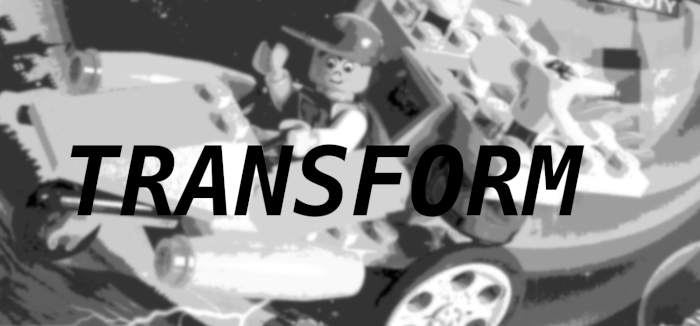
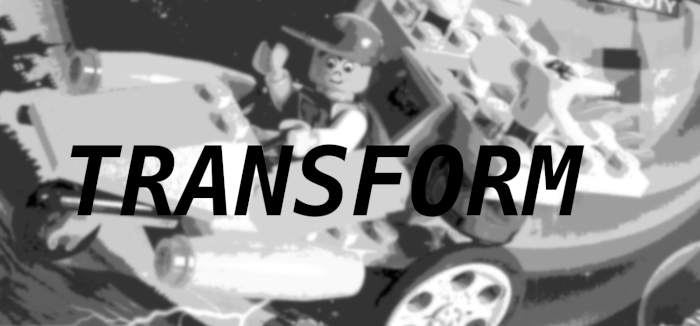

## THE TRANSFORM STEP

This section turns the raw, freshly merged data into a clean and publishable dataset. Each transformation is a **pure function** it takes a DataFrame, returns a new one, and has no side effects.

Compose small, focused functions: the **single responsibility principle** is the paradigm where each function does exactly one thing. Why? It is easier to test, debug, and replace independently.

```text
    (EXTRACT)
    Raw API Data
    ↓
    (TRANSFORM)
1. Type parsing (datetime, numeric)
2. Column renaming (French → English)
3. Categorical mapping (validation status, quality)
4. Derived columns computation (flood alert flags)
5. Column reordering (logical grouping)
6. Sorting & index reset
    ↓
    (LOAD)
    Publication-ready dataset
```

First go through all the functional components. They will be glued together by a function at the end of the transform section. 

### Type parsing

#### Why convert types?

When data arrives from a CSV or a JSON API, everything is a **string** by default. Pandas needs to know the correct types to:

- Sort dates chronologically
- Do date arithmetics (`last_date + timedelta(days=1)`)
- Compare numeric values (`water_level > 6000`)
- Group and aggregate correctly

#### The solution: graceful coercion

Prevent a single bad row from crashing the entire pipeline by converting data from one type to another in a forgiving, non-destructive way.

Both functions use `errors="coerce"`:

- For datetimes: unparseable strings → `NaT` (Not a Time)
- For numbers: unparseable strings → `NaN`

#### `df.copy()` : immutability by convention

Every function starts with `df = df.copy()` so the function does **not** modify the caller's DataFrame.

In [14]:
def convert_to_date(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    """Convert specified columns to pandas datetime type.

    Handles:
    - Valid ISO dates: "2026-01-15" → datetime
    - Bad dates: "not a date" → NaT (Not a Time, pandas' null for datetimes)
    - Missing values: NaN → NaT

    Args:
        df: Input DataFrame
        columns: Column names to process

    Returns:
        New DataFrame with parsed and validated datetime columns
    """
    df = df.copy()  # Never modify the original!

    for col in columns:
        if col in df.columns:
            # errors='coerce' converts unparseable values to NaT
            df[col] = pd.to_datetime(df[col], errors="coerce").dt.normalize()

    return df


def convert_to_numeric(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    """Convert specified columns to numeric (float) type.

    Handles:
    - Valid numbers: 5800, "5800.5" → float
    - Bad numbers: "N/A", "unknown" → NaN
    - Missing values: NaN → NaN (unchanged)

    Args:
        df: Input DataFrame
        columns: Column names to process

    Returns:
        New DataFrame with parsed and validated numeric columns
    """
    df = df.copy()

    for col in columns:
        if col in df.columns:
            # errors='coerce' converts unparseable values to NaN
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

Test with messy data :

In [15]:
messy_df = pd.DataFrame({
    "date_obs_elab": ["2026-01-15", "2026-01-16", "not a date", None],
    "resultat_obs_elab": [5800.0, "5900", "N/A", None],
})

print("BEFORE type conversion:")
print(messy_df)
print(f"\nTypes: {messy_df.dtypes.to_dict()}")

type_safe_df = convert_to_date(messy_df, ["date_obs_elab"])
type_safe_df = convert_to_numeric(type_safe_df, ["resultat_obs_elab"])

print("\nAFTER type conversion:")
print(type_safe_df)
print(f"\nTypes: {type_safe_df.dtypes.to_dict()}")

print("\nBad values coerced to NaT/NaN (pipeline continues safely)")

BEFORE type conversion:
  date_obs_elab resultat_obs_elab
0    2026-01-15            5800.0
1    2026-01-16              5900
2    not a date               N/A
3          None              None

Types: {'date_obs_elab': dtype('O'), 'resultat_obs_elab': dtype('O')}

AFTER type conversion:
  date_obs_elab  resultat_obs_elab
0    2026-01-15             5800.0
1    2026-01-16             5900.0
2           NaT                NaN
3           NaT                NaN

Types: {'date_obs_elab': dtype('<M8[ns]'), 'resultat_obs_elab': dtype('float64')}

Bad values coerced to NaT/NaN (pipeline continues safely)


<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Jupyter notebook info box">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
<div style="  color:lightblue;  margin-top:4px;  font-size:75%;  font-weight:300;  margin:0;  text-align:left;">  <div>    Don’t let one bad row kill the run: always coerce bad data to nulls rather than raising exceptions in a batch pipeline. Flag/log nulls separately.  </div></div>
</div>
    </div>
  </div>
</div>

<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Jupyter notebook info box">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
<div style="
  color:lightblue;
  margin-top:4px;
  font-size:75%;
  font-weight:300;
  margin:0;
  text-align:left;
">
  <div>
    Treat DataFrames as <strong>immutable</strong> inputs. Return a new DataFrame rather than modifying in place. This prevents subtle bugs where one function unexpectedly changes data seen by another (<a href="https://en.wikipedia.org/wiki/Side_effect_(computer_science)" target="_blank" rel="noopener noreferrer">side effect</a>).
  </div>
</div>
    </div>
  </div>
</div>

Wrap the two functions into one :

In [16]:
def auto_convert_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Auto-detect and convert datetime and numeric columns to the correct type.

    Analyzes column content to determine if columns should be parsed as
    datetimes or numerics, then applies appropriate type conversion.

    Args:
        df: Input DataFrame

    Returns:
        DataFrame with converted columns
    """
    datetime_cols = []
    numeric_cols = []

    for col in df.columns:
        # Skip columns that are already properly typed
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            continue

        # For object/string columns, infer the intended type
        if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):

            # Get a non-null sample to test
            sample = df[col].dropna().head(10)

            if len(sample) == 0:
                continue

            # Try datetime parsing first
            try:
                pd.to_datetime(sample, errors='raise', format='mixed')
                datetime_cols.append(col)
                continue
            except (ValueError, TypeError):
                pass

            # Try numeric parsing
            try:
                pd.to_numeric(sample, errors='raise')
                numeric_cols.append(col)
                continue
            except (ValueError, TypeError):
                pass

    # Apply conversion functions with detected columns
    df = convert_to_date(df, datetime_cols)
    df = convert_to_numeric(df, numeric_cols)

    return df

### Schema & mappings

#### The problem: two countries, two schemas

The Hub'Eau API returns French column names and categorical values. Materials targeting a broader audience should be published in English.

```
code_station         → station_code
date_obs_elab        → record_date
resultat_obs_elab    → water_level_mm
libelle_statut       → validation_status
...
```

#### Solution: bidirectional mappings

Define a **single, authoritative mapping** at the top of the module. Every rename in the pipeline goes through this mapping.

Create two mappings :

1. **API → English**: For initial data ingestion
2. **English → API**: For reversing operations, if needed (defensive programming)

This translates in code to:

```python
API_TO_EN = {"code_site": "location_code", ...}
EN_TO_API = {v: k for k, v in API_TO_EN.items()}  # Reverse mapping
```

The latter is derived programatically : `EN_TO_API` is the *inverse* of `API_TO_EN`. It is generated with a **dict comprehension**.

1) Define mappings for column names :

In [17]:
# ============================================================================
# SCHEMA MAPPINGS
# ============================================================================

# Primary mapping: French API columns to English column names
API_TO_EN = {
    "code_site": "location_code",
    "code_station": "station_code",
    "date_obs_elab": "record_date",
    "resultat_obs_elab": "water_level_mm",
    "date_prod": "data_production_date",
    "code_statut": "validation_status_code",
    "libelle_statut": "validation_status",
    "code_methode": "production_method_code",
    "libelle_methode": "production_method",
    "code_qualification": "quality_code",
    "libelle_qualification": "quality_assessment",
    "longitude": "longitude",
    "latitude": "latitude",
    "grandeur_hydro_elab": "hubeau_elab_code",
}

# Reverse mapping: English to French (computed automatically)
EN_TO_API = {v: k for k, v in API_TO_EN.items()}

print("API → English mapping sample:")
for api_col, en_col in list(API_TO_EN.items())[:5]:
    print(f"  {api_col:25} {en_col}")

print(f"\n{len(API_TO_EN)} column mappings defined")

API → English mapping sample:
  code_site                 location_code
  code_station              station_code
  date_obs_elab             record_date
  resultat_obs_elab         water_level_mm
  date_prod                 data_production_date

14 column mappings defined


2) Define mappings for the categorical columns :

In [18]:
# ============================================================================
# CATEGORICAL VALUE MAPPINGS
# ============================================================================

# Translation tables for categorical columns
CATEGORICAL_MAPPINGS = {
    "validation_status": {
        "Donnée validée": "validated",
        "Donnée brute": "raw",
        "Donnée pré-validée": "pre-validated",
    },
    "quality_assessment": {
        "Bonne": "good",
        "Non qualifiée": "unqualified",
        "Douteuse": "dubious",
    },
    "production_method": {
        "Calculée": "calculated",
        "Mesurée": "measured",
        "Expertisée": "expert-reviewed",
    },
}

print("Categorical mappings (French → English):")
for col_name, mapping in CATEGORICAL_MAPPINGS.items():
    print(f"\n  {col_name}:")
    for fr, en in mapping.items():
        print(f"    '{fr}' : '{en}'")

Categorical mappings (French → English):

  validation_status:
    'Donnée validée' : 'validated'
    'Donnée brute' : 'raw'
    'Donnée pré-validée' : 'pre-validated'

  quality_assessment:
    'Bonne' : 'good'
    'Non qualifiée' : 'unqualified'
    'Douteuse' : 'dubious'

  production_method:
    'Calculée' : 'calculated'
    'Mesurée' : 'measured'
    'Expertisée' : 'expert-reviewed'


Extract mappings into functions :

In [19]:
def rename_to_api_schema(df: pd.DataFrame) -> pd.DataFrame:
    """Rename English column names back to API schema names.

    Why? Defensive programming. If we need to re-export to API format.

    Best practice: use .copy() to avoid modifying original DataFrame
    (prevents unexpected side effects in calling code)

    Args:
        df: DataFrame with English column names

    Returns:
        New DataFrame with API column names (original unchanged)
    """
    if df.empty:
        return df.copy()

    # Only rename columns that exist (defensive)
    columns_to_rename = {k: v for k, v in EN_TO_API.items() if k in df.columns}
    return df.rename(columns=columns_to_rename)


def rename_to_english(df: pd.DataFrame) -> pd.DataFrame:
    """Rename API column names to English schema names.

    This is the main transformation we use during processing.
    Only rename when the target English column is not already present.

    Args:
        df: DataFrame with API column names

    Returns:
        New DataFrame with English column names (original unchanged)
    """

    if df.empty:
        return df.copy()

    columns_to_rename = {}
    for src, dst in API_TO_EN.items():
        if src in df.columns and dst not in df.columns:
            columns_to_rename[src] = dst

    return df.rename(columns=columns_to_rename)

In [20]:
# preserve any values that don't match.
def apply_categorical_mappings(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()
    for col_name, mapping in CATEGORICAL_MAPPINGS.items():
        if col_name in df.columns:
            df[col_name] = df[col_name].map(mapping).fillna(df[col_name])
    return df

Validation :

In [21]:
# Test the functions
sample_api_df = pd.DataFrame({
    "code_station": ["F700000109"],
    "date_obs_elab": ["2024-01-15"],
    "resultat_obs_elab": [5800.0],
    "libelle_statut": ["Donnée validée"],
})

print("Original (API Schema):")
print(sample_api_df.columns.tolist())

renamed_df = rename_to_english(sample_api_df)
print("\nAfter rename_to_english():")
print(renamed_df.columns.tolist())

reversed_df = rename_to_api_schema(renamed_df)
print("\nAfter rename_to_api_schema() [should match original]:")
print(reversed_df.columns.tolist())

print("\nRound-trip rename successful (bidirectional mapping works).")

Original (API Schema):
['code_station', 'date_obs_elab', 'resultat_obs_elab', 'libelle_statut']

After rename_to_english():
['station_code', 'record_date', 'water_level_mm', 'validation_status']

After rename_to_api_schema() [should match original]:
['code_station', 'date_obs_elab', 'resultat_obs_elab', 'libelle_statut']

Round-trip rename successful (bidirectional mapping works).


<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Jupyter notebook info box">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
<div style="
  color:lightblue;
  margin-top:4px;
  font-size:75%;
  font-weight:300;
  margin:0;
  text-align:left;
">
  <div>
    <i>Single source of truth</i> : define your schema translation once. This means a column rename is a <strong>one-line change</strong>. If <code style="font-family:inherit;">API_TO_EN</code> changes, <code style="font-family:inherit;">EN_TO_API</code> updates automatically.
  </div>
</div>
    </div>
  </div>
</div>

<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Jupyter notebook info box">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
<div style="
  color:lightblue;
  margin-top:4px;
  font-size:75%;
  font-weight:300;
  margin:0;
  text-align:left;
">
  <div>
    Make utility functions robust to partial inputs. A rename function that crashes when a column is missing is fragile. Filter the mapping dict to only keys present in the DataFrame.
  </div>
</div>
</div>
    </div>
  </div>
</div>

Compute derived data :

In [22]:
def add_derived_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Add computed columns based on raw data.

    Currently adds:
    - flood_alert: Boolean flag if water_level_mm > flood_threshold_mm

    Why add derived columns?
    - Helps downstream analysis (filtering, alerting)
    - Pre-computed in ETL = faster queries
    - Logic centralized in pipeline

    Args:
        df: DataFrame with English column names

    Returns:
        New DataFrame with derived columns
    """
    df = df.copy()

    if "water_level_mm" in df.columns:
        df["flood_alert"] = df["water_level_mm"] > STATION_CONFIG.flood_threshold_mm

    return df

### Columns ordering

<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Jupyter notebook info box">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
<div style="
  color:lightblue;
  margin-top:4px;
  font-size:75%;
  font-weight:300;
  margin:0;
  text-align:left;
">
  <div>
    <ol style="margin:0; padding-left:18px;">
      <li>Keep identifiers and key reference fields upfront.</li>
      <li>Put the most important, most frequently used, and most stable columns first.</li>
      <li>Group related fields together so the <em>table reads naturally</em>.</li>
      <li>Place optional or rarely used fields later.</li>
    </ol>
  </div>
</div>
</div>
    </div>
  </div>
</div>

In [23]:
# ============================================================================
# COLUMN ORDERING
# ============================================================================

# User defined preferred column order (logical grouping)
COLUMN_ORDER = [
    # Primary identifiers & measurements
    "station_code",
    "record_date",
    "water_level_mm",
    "flood_alert",  # Derived metric (computed)

    # Metadata about the observation
    "hubeau_elab_code",
    "data_production_date",
    "validation_status_code",
    "validation_status",
    "production_method_code",
    "production_method",
    "quality_code",
    "quality_assessment",

    # Geographic info (less important)
    "location_code",
    "longitude",
    "latitude",
]

print(f"Column order defined: {len(COLUMN_ORDER)} columns")
print(f"Priority: IDs & measurements → metadata → geography")

Column order defined: 15 columns
Priority: IDs & measurements → metadata → geography


Implementation :

In [24]:
def order_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Reorder columns to preferred order.

    Why reorder?
    - Logical grouping (IDs, measurements, metadata, geography)
    - User experience (most important columns first)
    - Consistency across runs

    Args:
        df: DataFrame with any column order

    Returns:
        DataFrame with reordered columns
    """
    # Columns in preferred order that exist
    present_cols = [c for c in COLUMN_ORDER if c in df.columns]
    # Remaining columns (if any)
    other_cols = [c for c in df.columns if c not in present_cols]

    return df[present_cols + other_cols]

### Deduplication

#### The problem: duplicate records

In an incremental pipeline, date ranges and records can overlap :

- We might re-fetch a day we already have (API data arrives late)
- The same observation might appear in two API pages
- The scheduled script might run twice by accident

Without deduplication, we'd accumulate duplicates in the dataset.

#### The solution: deduplication key

Define what makes a record **unique** :

```
# This is what we call a composite key
key = (station_code, observation_date, water_level_value)
```

#### Why this key ?

This combination should be unique in the physical world: one sensor, one day, one daily maximum water level reading.

- **station_code**: records from different stations can't be duplicates.
- **observation_date**: two readings on different days aren't duplicates.
- **water_level_mm**: same station+date but different levels = different observation.

If two records share the same key, keep only the first occurrence.

<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Jupyter notebook info box">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      📚
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Tip</b>
      </div>
<div style="
  color:lightblue;
  margin-top:4px;
  font-size:75%;
  font-weight:300;
  margin:0;
  text-align:left;
">
  <div>
Make deduplication keys immutable <i>(date+value+ID)</i>.
  </div>
</div>
</div>
    </div>
  </div>
</div>

In [25]:
def create_dedup_key(df: pd.DataFrame) -> pd.Series:
    """Create unique deduplication key from station, day, and water level value.

    Key format: "station_code_YYYY-MM-DD_value"
    Example: "F700000109_2024-01-15_5800.0"

    Why this format?
    - Readable (human-inspectable)
    - Hashable (can use in sets for fast lookup)
    - Immutable components (no time-of-day, just date)

    Args:
        df: DataFrame

    Returns:
        Series of deduplication keys (NaN for rows with missing components)
    """
    parts = []

    # Station code
    if "code_station" in df.columns:
        parts.append(df["code_station"].astype(str))

    # Date (day only, no time)
    if "date_obs_elab" in df.columns:
        parts.append(df["date_obs_elab"].dt.strftime("%Y-%m-%d"))

    # Water level value
    if "resultat_obs_elab" in df.columns:
        parts.append(df["resultat_obs_elab"].astype(str))

    if not parts:
        return pd.Series(index=df.index, dtype="object")

    # Combine parts with underscore separator
    return pd.Series(
        ["_".join(row) for row in zip(*parts)],
        index=df.index
    )

Validation :

In [26]:
# Test
test_std_df = pd.DataFrame({
    "code_station": ["F700000109", "F700000110"],
    "date_obs_elab": pd.to_datetime(["2026-01-15", "2026-01-16"]),
    "resultat_obs_elab": [5800.0, 5900.0],
})

keys = create_dedup_key(test_std_df)
print("Deduplication Keys:")
print(keys.tolist())

print("\nKeys are unique, human-readable, and immutable")

Deduplication Keys:
['F700000109_2026-01-15_5800.0', 'F700000110_2026-01-16_5900.0']

Keys are unique, human-readable, and immutable


<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Jupyter notebook info box">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
<div style="
  color:lightblue;
  margin-top:4px;
  font-size:75%;
  font-weight:300;
  margin:0;
  text-align:left;
">
  <div>
    Using a <code style="font-family:inherit;">set</code> for the existing keys means each membership test is <strong>O(1)</strong> while checking against a list would be <strong>O(n)</strong> per test (catastrophic for large datasets!).
  </div>
</div>
</div>
    </div>
  </div>
</div>

Achievements so far :

1) Robust types (columns) 
2) Robust key

**Next step** : safely clean.

In [27]:
def remove_duplicates(existing: pd.DataFrame, new: pd.DataFrame) -> pd.DataFrame:
    """Remove rows from 'new' that already exist in 'existing'.

    Algorithm:
    1. Enforce types in both DataFrames
    2. Create dedup keys for both
    3. Find keys in 'existing'
    4. Filter 'new' to exclude those keys
    5. Return only the truly new rows

    Args:
        existing: existing dataset (any schema)
        new: new data to filter (same schema as existing)

    Returns:
        Copy of 'new' with duplicate rows removed
    """
    # Short-circuit: if either is empty, no work to do
    if existing.empty or new.empty:
        return new.copy()

    # Parse types to both for comparison
    existing_std = auto_convert_columns(existing)
    new_std = auto_convert_columns(new)

    # Create dedup keys
    existing_keys = set(create_dedup_key(existing_std).dropna())
    new_keys = create_dedup_key(new_std)

    # Boolean mask: True where the new row is genuinely new
    mask = ~new_keys.isin(existing_keys)

    # Return only new rows (preserve original schema)
    # Index back into original (non-standardised) 'new' to preserve all columns
    result = new.iloc[new_keys[mask].index].copy()

    return result

Validation :

In [28]:
# Test with duplicate scenario
existing_test_data = pd.DataFrame({
    "code_station": ["F700000109", "F700000109"],
    "date_obs_elab": ["2026-01-15", "2026-01-16"],
    "resultat_obs_elab": [5800.0, 5850.0],
})

new_test_data = pd.DataFrame({
    "code_station": ["F700000109", "F700000109", "F700000110"],
    # First row is duplicate
    "date_obs_elab": ["2026-01-15", "2026-01-17", "2026-01-17"],
    "resultat_obs_elab": [5800.0, 5900.0, 6100.0],
})

print("Existing data (2 rows):")
print(existing_test_data)

print("\nNew data (3 rows, 1 is duplicate):")
print(new_test_data)

deduped = remove_duplicates(existing_test_data, new_test_data)

print("\nAfter deduplication (2 rows):")
print(deduped)

print(f"\nRemoved {len(new_test_data) - len(deduped)} duplicate row(s), will append these two rows to the existing dataset.")

Existing data (2 rows):
  code_station date_obs_elab  resultat_obs_elab
0   F700000109    2026-01-15             5800.0
1   F700000109    2026-01-16             5850.0

New data (3 rows, 1 is duplicate):
  code_station date_obs_elab  resultat_obs_elab
0   F700000109    2026-01-15             5800.0
1   F700000109    2026-01-17             5900.0
2   F700000110    2026-01-17             6100.0

After deduplication (2 rows):
  code_station date_obs_elab  resultat_obs_elab
1   F700000109    2026-01-17             5900.0
2   F700000110    2026-01-17             6100.0

Removed 1 duplicate row(s), will append these two rows to the existing dataset.



### Wrap up : pipeline of small functions


In [29]:
def postprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Apply all post-processing transformations.

    The complete "Transform" pipeline:
    1. Enforce datetime and numeric types
    2. Rename to English schema
    3. Translate categorical values
    4. Add derived columns
    5. Reorder columns logically
    6. Sort by date and station & reset index

    Args:
        df: Raw API data (French schema)

    Returns:
        Fully processed, publication-ready dataset
    """
    if df.empty:
        return df

    df = df.copy()

    # Step 1: Type conversions
    print("  1. Converting types...")
    df = auto_convert_columns(df)

    # Step 2: Rename columns
    print("  2. Renaming columns (French → English)...")
    df = rename_to_english(df)

    # Step 3: Map categories
    print("  3. Mapping categorical values...")
    df = apply_categorical_mappings(df)

    # Step 4: Add computed columns
    print("  4. Adding derived columns...")
    df = add_derived_columns(df)

    # Step 5: Organize columns
    print("  5. Reordering columns...")
    df = order_columns(df)

    # Step 6: Sort and reset index
    print("  6. Sorting and resetting index...")
    df = df.sort_values(["record_date", "station_code"]).reset_index(drop=True)

    return df

Validation :

In [30]:
# Test the full postprocessing pipeline
print("Processing raw API data...")
raw_data_fr = rename_to_english(raw_data)
raw_data_fr = apply_categorical_mappings(raw_data_fr)

processed_mock_data = postprocess(raw_data_fr)

print(f"\nProcessing complete: {len(processed_mock_data)} rows")
print(f"\nFirst row (processed, English schema):")
print(processed_mock_data.iloc[0])

print(f"\nColumn order verified: ")
print(processed_mock_data.columns.tolist())

Processing raw API data...
  1. Converting types...
  2. Renaming columns (French → English)...
  3. Mapping categorical values...
  4. Adding derived columns...
  5. Reordering columns...
  6. Sorting and resetting index...

Processing complete: 35 rows

First row (processed, English schema):
station_code                  mock_F700000102
record_date               2026-01-15 00:00:00
water_level_mm                           5502
flood_alert                             False
hubeau_elab_code                   mock_HIXnJ
data_production_date      2026-01-16 00:00:00
validation_status_code                      1
validation_status                         raw
production_method_code                      1
production_method                    measured
quality_code                                1
quality_assessment                unqualified
location_code                  mock_700000102
longitude                            2.356927
latitude                            48.857782
Name: 0, dtype:

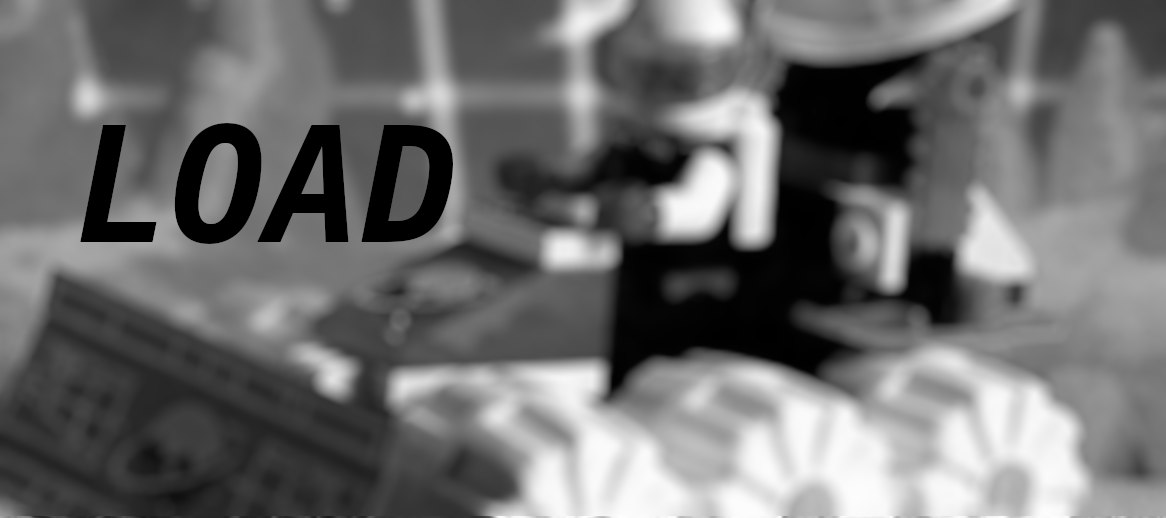

## THE LOAD STEP

This is the final stage of every ETL pipeline : it involves taking the processed data from the transformation phase and moving it into a target system or destination. Destination targets typically include data warehouses, data lakes, databases, data marts, or business intelligence tools. 

The mock pipeline saves a CSV locally for demo purposes while the full pipeline replicates the [original script's](https://www.kaggle.com/code/grimespoint/paris-flood-dataset-weekly-updater) behaviour. It will update the original [Paris Flood dataset](https://www.kaggle.com/datasets/grimespoint/paris-flood-dataset).

📌

If you run a copy of this notebook in your environment, make sure to have your own copy of the dataset and also **update the paths and slugs** to the correct locations (see [Config](#part-3-configuration-management-with-dataclasses)).

### Prepare for publication

Prepare the destination folder :

In [31]:
def create_output_dir(use_mock: bool = False) -> None:
    """Create output directory (and parents) if it does not already exist.

    Args:
        use_mock (bool): If True, use mock_output directory instead of configured output_dir.
    """
    output_dir = KAGGLE_CONFIG.mock_output_dir if use_mock else KAGGLE_CONFIG.output_dir
    output_dir.mkdir(parents=True, exist_ok=True)

    # exist_ok=True: idempotent : safe to call multiple times

In [32]:
create_output_dir(use_mock=False)

### Why metadata?

Kaggle requires a `dataset-metadata.json` file alongside the data CSV. It describes the dataset for additional info and search.

`subprocess.run`, calling CLI tools from python :

`publish_to_kaggle` invokes the Kaggle CLI (`kaggle datasets version`) via Python's `subprocess` module. This is a standard pattern for orchestrating external tools from a Python pipeline.

```python
subprocess.run(cmd, check=True)
# check=True → raises CalledProcessError if the command exits with non-zero status
```

<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Jupyter notebook info box">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
<div style="
  color:lightblue;
  margin-top:4px;
  font-size:75%;
  font-weight:300;
  margin:0;
  text-align:left;
">
  <div>
    Use <code style="font-family:inherit;">check=True</code> with <code style="font-family:inherit;">subprocess.run</code> so that a failed CLI command propagates as an exception, not a silent success.<br/>
    Always build CLI arguments as a <strong>list</strong>, not a concatenated string. This avoids shell injection vulnerabilities and handles spaces in arguments correctly.
  </div>
</div>


</div>
    </div>
  </div>
</div>

In [33]:
def create_metadata(df: pd.DataFrame, config: KaggleConfig) -> Dict:
    """Generate Kaggle dataset metadata from DataFrame and config.

    - Dataset discoverability (keywords, title)
    - Usage rights (license)
    - Data freshness (temporal coverage)
    - Geographic context

    Args:
        df: Processed DataFrame with 'record_date' column
        config: KaggleConfig instance

    Returns:
        Dictionary in Kaggle-compatible format
    """
    if df.empty or "record_date" not in df.columns:
        first_date = "unknown"
        last_date = "unknown"
    else:
        first_date = df["record_date"].min().strftime("%Y-%m-%d")
        last_date = df["record_date"].max().strftime("%Y-%m-%d")

    metadata = {
        "title": config.title,
        "id": config.dataset_slug,
        "licenses": [{"name": config.license_name}],
        "keywords": config.keywords,
        "temporalCoverage": {
            "startDate": first_date,
            "endDate": last_date,
        },
        "geospatialCoverage": config.geospatial_coverage,
        "updateFrequency": config.update_frequency,
    }

    return metadata

# Generate metadata
create_output_dir(use_mock=True)
metadata = create_metadata(processed_mock_data, KAGGLE_CONFIG)

print("Dataset Metadata:")
print(json.dumps(metadata, indent=2))

# Save metadata to JSON
metadata_path = KAGGLE_CONFIG.mock_output_dir
dataset_meta_file = metadata_path / KAGGLE_CONFIG.metadata_filename

with open(dataset_meta_file, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"\nMetadata saved to {metadata_path}")

Dataset Metadata:
{
  "title": "Paris flood dataset",
  "id": "grimespoint/paris-flood-dataset",
  "licenses": [
    {
      "name": "CC0-1.0"
    }
  ],
  "keywords": [
    "tabular",
    "weather and climate",
    "environment",
    "europe",
    "time series analysis"
  ],
  "temporalCoverage": {
    "startDate": "2026-01-15",
    "endDate": "2026-01-21"
  },
  "geospatialCoverage": "Paris, France",
  "updateFrequency": "Weekly"
}

Metadata saved to mock_output


## THE FULL ETL PIPELINE

Assemble all components into a single workflow.

### The global rehearsal

Mock data power :

In [34]:
print(mock_api_response)

[{'code_site': 'mock_700000109', 'code_station': 'mock_F700000109', 'date_obs_elab': '2026-01-15', 'resultat_obs_elab': 5613, 'date_prod': '2026-01-16', 'code_statut': '1', 'libelle_statut': 'Donnée validée', 'code_methode': '1', 'libelle_methode': 'Calculée', 'code_qualification': '1', 'libelle_qualification': 'Non qualifiée', 'longitude': 2.3613240703845917, 'latitude': 48.85669085890734, 'grandeur_hydro_elab': 'mock_HIXnJ'}, {'code_site': 'mock_700000109', 'code_station': 'mock_F700000109', 'date_obs_elab': '2026-01-16', 'resultat_obs_elab': 5453, 'date_prod': '2026-01-17', 'code_statut': '1', 'libelle_statut': 'Donnée pré-validée', 'code_methode': '1', 'libelle_methode': 'Mesurée', 'code_qualification': '1', 'libelle_qualification': 'Bonne', 'longitude': 2.346458570150563, 'latitude': 48.856335733998414, 'grandeur_hydro_elab': 'mock_HIXnJ'}, {'code_site': 'mock_700000109', 'code_station': 'mock_F700000109', 'date_obs_elab': '2026-01-17', 'resultat_obs_elab': 5661, 'date_prod': '202

Run the pipeline in mock mode. No push on Kaggle at this step yet, only store the CSV in the output folder.

In [35]:
def run_etl_pipeline(use_mock: bool = True) -> pd.DataFrame:
    """Run the complete ETL pipeline: Extract → Transform → Load to CSV.

    Returns:
        Processed DataFrame ready for publication
    """
    print("\n" + "="*70)
    print("PARIS FLOOD DATASET ETL PIPELINE")
    print("="*70)

    # ====================================================================
    # STEP 1: LOAD EXISTING DATA
    # ====================================================================

    if use_mock:
        print("\n=== mock pipeline ===")
        print("\n[STEP 1] Loading mock dataset...")
        # For demo, use a sample existing dataset
        loaded_df = pd.DataFrame(mock_api_response)
        loaded_df['date_obs_elab'] = pd.to_datetime(loaded_df['date_obs_elab'])

        # Demo : translate in english here (mimic loaded CSV)
        loaded_df = rename_to_english(loaded_df)
        print(f"  Loaded {len(loaded_df)} existing records")

    else:
        print("\n=== API pipeline ===")
        print("\n[STEP 1] Loading existing dataset...")
        loaded_df = load_csv(KAGGLE_CONFIG.input_csv)
        print(f"  {len(loaded_df):,} existing rows loaded.")

    # ====================================================================
    # STEP 2: DETERMINE UPDATE RANGE
    # ====================================================================
    print("\n[STEP 2] Determining update range...")
    should_update, start_date = determine_update_range(loaded_df)
    if not should_update:
        print("\n Dataset is current. Returning existing data.")
        return loaded_df

    # ====================================================================
    # STEP 3: EXTRACT (FETCH DATA)
    # ====================================================================
    print(f"\n[STEP 3] Extracting data from {start_date})...")
    fetched_data = fetch_all_data(start_date, use_mock=use_mock)
    print(f"  Extracted {len(fetched_data)} raw records")

    # ====================================================================
    # STEP 4: TRANSFORM I : DEDUPLICATE
    # ====================================================================
    print("\n[STEP 4] Deduplicating against existing data...")
    deduped_fetched_data = remove_duplicates(loaded_df, fetched_data)
    print(f"  Removed {len(fetched_data) - len(deduped_fetched_data)} duplicates")
    print(f"  {len(deduped_fetched_data)} truly new records to add")

    # ====================================================================
    # STEP 5: TRANSFORM II : COMBINE (MERGE WITH EXISTING)
    # ====================================================================
    print("\n[STEP 5] Merging new data with existing...")
    # Translate fetched data into English (match loaded_df) before combining
    new_df_english = rename_to_english(deduped_fetched_data)
    merged_historical_and_new = pd.concat([loaded_df, new_df_english], ignore_index=True)
    print(f"  Combined dataset: {len(merged_historical_and_new)} total records")

    # ====================================================================
    # STEP 6: TRANSFORM III : POST-PROCESS
    # ====================================================================
    print("\n[STEP 6] Postprocessing data...")
    processed_records = postprocess(merged_historical_and_new)
    print(f"  Transformation complete")

    # ====================================================================
    # STEP 7: EXPORT (LOAD TO CSV)
    # Mock exports only mock CSV
    # For real world behaviour, set mock=False in the later section
    # ====================================================================
    print("\n[STEP 7] Exporting to CSV...")

    create_output_dir(use_mock=use_mock)

    if use_mock:
        output_path = KAGGLE_CONFIG.mock_output_filename
    else:
        output_path = KAGGLE_CONFIG.output_csv_path

    processed_records.to_csv(output_path, index=False, sep=",")

    file_size_kb = os.path.getsize(output_path) / 1024
    print(f"  Exported to {output_path}")
    print(f"  File size: {file_size_kb:.1f} KB")

    print("\n" + "="*70)
    print("ETL PIPELINE COMPLETE")
    print("="*70)

    return processed_records


# Run the pipeline
mock_dataset = run_etl_pipeline(use_mock=True)


PARIS FLOOD DATASET ETL PIPELINE

=== mock pipeline ===

[STEP 1] Loading mock dataset...
  Loaded 5 existing records

[STEP 2] Determining update range...
Last day in dataset: 2026-01-19
Yesterday: 2026-07-05

Will retrieve data starting from: 2026-01-20

[STEP 3] Extracting data from 2026-01-20)...
Fetching data for station F700000109...
  Got 7 records
Fetching data for station F700000110...
  Got 7 records
Fetching data for station F700000111...
  Got 7 records
Fetching data for station F700000102...
  Got 7 records
Fetching data for station F700000103...
  Got 7 records
  Extracted 35 raw records

[STEP 4] Deduplicating against existing data...
  Removed 0 duplicates
  35 truly new records to add

[STEP 5] Merging new data with existing...
  Combined dataset: 40 total records

[STEP 6] Postprocessing data...
  1. Converting types...
  2. Renaming columns (French → English)...
  3. Mapping categorical values...
  4. Adding derived columns...
  5. Reordering columns...
  6. Sorting

### The real deal

```python
loaded_df                 = load_csv(...)                          # 1. load existing data
should_update, start_date = determine_update_range                 # 2. check what's needed
fetched_data              = fetch_all_data(start_date)             # 3. fetch new records
deduped_fetched_data      = remove_duplicates(existing, new_raw)   # 4. deduplicate
merged_historical_and_new = pd.concat([existing, new_clean])       # 5. merge
processed_records         = postprocess(merged_historical_and_new) # 6. postprocess
processed_records.to_csv(...)                                      # 7. save
write_metadata() + publish_to_kaggle()                             # 8. publish
```

Linear, each step's intent is obvious.

Handles genuine data. This involves additionnal steps like metadata handling and publication on the Kaggle platform.

In [36]:
def write_metadata(df: pd.DataFrame) -> None:
    """Write dataset metadata to JSON file.

    Calls create_metadata to generate content and writes to path specified
    in KAGGLE_CONFIG.metadata_path.

    Args:
        df (pd.DataFrame): Processed DataFrame to extract temporal coverage from.

    Raises:
        IOError: If file writing fails.
    """
    metadata = create_metadata(df, KAGGLE_CONFIG)

    with open(KAGGLE_CONFIG.metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    print(f"Metadata written to {KAGGLE_CONFIG.metadata_path}")

N.B. **Only the dataset owner can publish new versions**. You need to fork the notebook and the dataset and once you have your owns, don' t forget to modify the slugs in the [KAGGLE_CONFIG section](#configuration-management-with-dataclasses).

In [37]:
def publish_to_kaggle() -> None:
    """Publish the updated dataset to Kaggle using the Kaggle CLI.

    Runs 'kaggle datasets version' command with current output directory.
    Includes timestamp in the version message.

    Raises:
        subprocess.CalledProcessError: If Kaggle CLI command fails.
    """
    timestamp = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
    message = f"Weekly update: {timestamp}"

    cmd = [
        "kaggle",
        "datasets",
        "version",
        "-p",
        str(KAGGLE_CONFIG.output_dir),
        "-m",
        message,
        "--dir-mode",
        "zip",
    ]

    print("Publishing to Kaggle...")
    print("Command:", " ".join(cmd))

    try:
        subprocess.run(cmd, check=True)
        print("Successfully published to Kaggle.")
    except subprocess.CalledProcessError as e:
        print(f"Error publishing to Kaggle: {e}")
        raise

### Analysis & validation

In [38]:
def validate_and_analyze(df: pd.DataFrame) -> None:
    """Perform post-pipeline validation and analysis.

    Checks:
    - No unexpected null values
    - Correct data types
    - Data range sanity
    - Flood alerts computed
    """
    print("\n" + "="*40)
    print("DATA VALIDATION & ANALYSIS")
    print("="*40)

    print(f"\nDataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")

    print("\nData Types:")
    for col, dtype in df.dtypes.items():
        print(f"  {col:30} {str(dtype):15}")

    print("\nNull Values:")
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0]
    if len(null_cols) == 0:
        print("  No null values found")
    else:
        for col, count in null_cols.items():
            pct = (count / len(df)) * 100
            print(f"  {col:30} {count:5} ({pct:5.1f}%)")

    print("\nWater Level Statistics (mm):")
    water_level_stats = df["water_level_mm"].describe()
    for stat_name, value in water_level_stats.items():
        if pd.notna(value):
            print(f"  {stat_name:10} {value:10.1f}")

    print(
        f"\nFlood Alerts (threshold: {STATION_CONFIG.flood_threshold_mm}mm):")
    flood_count = df["flood_alert"].sum()
    flood_pct = (flood_count / len(df)) * 100 if len(df) > 0 else 0
    print(f"  {flood_count} records ({flood_pct:.1f}%) exceed threshold")

    print(f"\nTemporal Coverage:")
    print(f"  From: {df['record_date'].min()}")
    print(f"  To:   {df['record_date'].max()}")
    days_span = (df['record_date'].max() - df['record_date'].min()).days
    print(f"  Span: {days_span} days")

    print(f"\nStations Covered:")
    stations = df["station_code"].unique()
    for i, station in enumerate(sorted(stations), 1):
        count = (df["station_code"] == station).sum()
        print(f"  {i}. {station}: {count} records")

    print(f"\nData Quality Summary:")
    print(
        f"  Validation Status Categories: {df['validation_status'].nunique()}")
    print(
        f"  Quality Assessment Categories: {df['quality_assessment'].nunique()}")

    print("\n" + "="*70)

### Pipeline orchestration with `main()`

The `main()` function is the **conductor** that wires together every component built so far in the correct order. Nothing new happens here: it's pure sequencing.

In [39]:
def main() -> None:
    """Execute the full Paris Flood Monitoring ETL pipeline.

    Flow:

    EXTRACT
    1. Load the existing dataset from the Kaggle input mount
    2. Determine whether an update is needed (and from what date)
    3. Fetch new data from the Hub'Eau API

    TRANSFORM
    4. Deduplicate against the existing dataset
    5. Combine and post-process (type parsing, translation, derived cols...)

    LOAD
    6. Write the updated CSV and metadata file
    7. Publish the new dataset version to Kaggle

    Exits early (code 0) if the dataset is already up to date.
    """
    print("=" * 70)
    print("Paris Flood Monitoring : ETL Pipeline (with real API calls)")
    print("=" * 70)

    final_dataset = run_etl_pipeline(use_mock=False)
    final_dataset.to_csv(KAGGLE_CONFIG.output_csv_path, index=False)
    print(f"      CSV written to {KAGGLE_CONFIG.output_csv_path}")
    write_metadata(final_dataset)

    print("\n[FINAL STEP] Publishing to Kaggle...")
    publish_to_kaggle()

    print("\n API Pipeline complete.")

    print("Running post-run validation")
    validate_and_analyze(final_dataset)

The `if __name__ == "__main__":` is the guard

```python
if __name__ == "__main__":
    main()
```

means:

- Run as a script (`python script.py`) → `main()` is called
- Imported as a module (`import script`) → `main()` is **not** called automatically

<div style="display:flex;justify-content:center;padding:10px 0;" aria-label="Jupyter notebook info box">
  <div style="
    text-align:center;
    border-radius:15px;
    padding:15px;
    color:#4A90E2;
    margin:0;
    font-family:'Serif';
    background:
      radial-gradient(circle at 20% 30%, rgba(46, 139, 87, 0.4) 0%, transparent 50%),
      radial-gradient(circle at 75% 60%, rgba(30, 144, 255, 0.35) 0%, transparent 45%),
      radial-gradient(circle at 85% 20%, rgba(32, 178, 170, 0.3) 0%, transparent 40%),
      radial-gradient(circle at 10% 80%, rgba(0, 119, 182, 0.35) 0%, transparent 50%),
      linear-gradient(135deg, #0A1F3F 0%, #1A3A52 100%);
    box-shadow:0px 0px 16px rgba(74, 144, 226, 0.15);
    overflow:hidden;
    margin-bottom:1em;
    border:1px solid rgba(74, 144, 226, 0.2);
    max-width:760px;
    width:100%;
    box-sizing:border-box;
    display:flex;
    gap:12px;
    align-items:flex-start;
    justify-content:center;
  ">
    <div style="width:36px;height:36px;display:flex;align-items:center;justify-content:center;flex-shrink:0;">
      🧩
    </div>
    <div style="flex:1;">
      <div style="
        font-size:120%;
        color:cornflower;
        margin:0;
        text-align:left;
      ">
        <b>Best practice</b>
      </div>
<div style="
  color:lightblue;
  margin-top:4px;
  font-size:75%;
  font-weight:300;
  margin:0;
  text-align:left;
">
  <div>
    Always protect your entry point with <code style="font-family:inherit;">if __name__ == &quot;__main__&quot;:</code>. It makes the module importable (for testing, for example) without triggering side effects.
  </div>
</div>

</div>
    </div>
  </div>
</div>

In [40]:
if __name__ == "__main__":
    main()

Paris Flood Monitoring : ETL Pipeline (with real API calls)

PARIS FLOOD DATASET ETL PIPELINE

=== API pipeline ===

[STEP 1] Loading existing dataset...
  0 existing rows loaded.

[STEP 2] Determining update range...
No existing data found. Will fetch all data from earliest date.

[STEP 3] Extracting data from 1900-01-01)...
Fetching data for station F700000109...
  Got 24104 records
Fetching data for station F700000110...
  Got 2920 records
Fetching data for station F700000111...
  Got 5842 records
Fetching data for station F700000102...
  Got 13277 records
Fetching data for station F700000103...
  Got 7444 records
  Extracted 53587 raw records

[STEP 4] Deduplicating against existing data...
  Removed 0 duplicates
  53587 truly new records to add

[STEP 5] Merging new data with existing...
  Combined dataset: 53587 total records

[STEP 6] Postprocessing data...
  1. Converting types...
  2. Renaming columns (French → English)...
  3. Mapping categorical values...
  4. Adding derived

100%|██████████| 6.91M/6.91M [00:00<00:00, 9.15MB/s]


Upload successful: paris_flood_dataset.csv (7MB)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/grimespoint/paris-flood-dataset
Successfully published to Kaggle.

 API Pipeline complete.
Running post-run validation

DATA VALIDATION & ANALYSIS

Dataset Shape: 53587 rows x 15 columns

Data Types:
  station_code                   object         
  record_date                    datetime64[ns] 
  water_level_mm                 float64        
  flood_alert                    bool           
  hubeau_elab_code               object         
  data_production_date           datetime64[ns, UTC]
  validation_status_code         int64          
  validation_status              object         
  production_method_code         int64          
  production_method              object         
  quality_code                   int64          
  quality_assessment             object         
  location_code                  object         
  longitude        

## Summary

### What is Learned

#### Configuration

Parametrize behaviour 

| Practice | Example in this notebook |
|:---|:---|
| [Centralise all settings in one place](#why-dataclasses-) | `APIConfig`, `StationConfig`, `KaggleConfig` |
| [Use `@dataclass`](https://docs.python.org/3/library/dataclasses.html) over plain dicts | Type safety, IDE support, auto `__repr__` |
| [Avoid mutable default arguments](https://realpython.com/python-optional-arguments/) | `field(default_factory=list)` instead of `= []` |
| [Compute derived values once](https://realpython.com/python-data-classes/#comparing-cards) and also [$^{1}$](https://www.oreilly.com/library/view/fluent-python-2nd/9781492056348/ch05.html) | `__post_init__` for paths computed from slug |

#### Functions & Data Handling
| Practice | Example |
|:---|:---|
| [Deduplication](#deduplication) | Define immutable dedup key upfront |
| [Update Logic](#incremental-update-logic) | Avoid redundant fetches : check last data date, fetch incrementally |
| [Never mutate input DataFrames](#dfcopy--immutability-by-convention) | `df = df.copy()` at the start of every function |
| [Return consistent types](#what-is-graceful-file-loading-) | `load_csv` always returns a DataFrame (empty or not) |
| [Short-circuit on empty inputs](#deduplication) | `if df.empty: return df.copy()` guard clauses |
| [One function, one responsibility](#fetching-data) | separate concerns : `convert_to_date` vs `rename_to_english` |
| Use [vectorised](https://stackoverflow.com/questions/21156467/vectorization-in-pandas) pandas [operations](https://pandas.pydata.org/pandas-docs/stable/user_guide/enhancingperf.html) | [`.map()`](https://stackoverflow.com/questions/38440530/pandas-map-vs-apply-performance) and [$^{1}$](https://stackoverflow.com/questions/14233044/fastest-way-to-map-values-in-pandas), [`.isin()`](https://stackoverflow.com/questions/24834343/fastest-way-to-filter-a-pandas-dataframe-based-on-a-list) and [$^{2}$](https://stackoverflow.com/questions/45353502/pandas-isin-performance), [`.dt.strftime()`](https://stackoverflow.com/questions/34737247/efficient-way-to-format-dates-in-pandas) [avoid Python loops](https://stackoverflow.com/questions/12131311/how-to-avoid-loops-in-pandas) |

#### Robustness
| Practice | Example |
|:---|:---|
| [Coerce bad data to nulls](#the-solution-graceful-coercion) | `errors="coerce"` in `pd.to_datetime` / `pd.to_numeric` |
| [Graceful API error handling](#fetching-data) | `try/except requests.RequestException` |
| [Idempotent I/O](#prepare-for-publication) | `exist_ok=True` in `os.makedirs` |
| [Set-based deduplication](#why-this-key-) | `O(1)` key lookup with `existing_keys = set(...)` |

#### Code Quality
| Practice | Example |
|:---|:---|
| [Derive data from one source](#solution-bidirectional-mappings) | `EN_TO_API = {v: k for k, v in API_TO_EN.items()}` |
| [Document with docstrings](https://google.github.io/styleguide/pyguide.html#docstrings) | Every public function has Args / Returns / Raises |
| [Type-annotate signatures](https://realpython.com/python-type-checking/) | `def fetch(...) -> pd.DataFrame:` |
| [Guard the entry point](#pipeline-orchestration-with-main) | `if __name__ == "__main__": main()` |
| [Log progress clearly](#wrap-up--pipeline-of-small-functions) | `print(f"[1/7] Loading existing dataset...")` |

### References & acknowledgements

- **HubEau API**: https://hubeau.eaufrance.fr/